In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

import warnings 
warnings.filterwarnings("ignore")

In [2]:
train=pd.read_csv("../data/processed/train.csv")
test=pd.read_csv("../data/processed/test.csv")

linear_train = pd.read_csv("../data/processed/linear_train.csv")
linear_test = pd.read_csv("../data/processed/linear_test.csv")

In [3]:
X_train = train.drop("price", axis=1)
y_train = train["price"]

X_test = test.drop("price", axis=1)
y_test = test["price"]

In [4]:
linear_X_train = linear_train.drop("price", axis=1)
linear_y_train = linear_train["price"]

linear_X_test = linear_test.drop("price", axis=1)
linear_y_test = linear_test["price"]

In [5]:
def evaluate_model(model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)

    return {
        "Train R²": train_r2,
        "Test R²": test_r2,
        "Train RMSE": train_rmse,
        "Test RMSE": test_rmse,
        "Train MAE": train_mae,
        "Test MAE": test_mae
    }

In [6]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso,ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

from xgboost import XGBRegressor

In [7]:
tree_models={
    "Decision Tree":DecisionTreeRegressor(random_state=42),
    "Random Forest":RandomForestRegressor(random_state=42),
    "AdaBoost":AdaBoostRegressor(random_state=42),
    "XGBoost":XGBRegressor(random_state=42,objective='reg:squarederror')
}

linear_models={
    "Linear Regression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "ElasticNet":ElasticNet(),
    "KNN":KNeighborsRegressor(),
    "SVR":SVR()
}

In [8]:
tree_results = []

for name, model in tree_models.items():

    score = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    score["Model"] = name

    tree_results.append(score)

tree_results = pd.DataFrame(tree_results)

tree_results = tree_results[
    [
        "Model",
        "Train R²",
        "Test R²",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE"
    ]
]

tree_results.sort_values(
    by="Test R²",
    ascending=False
)

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
3,XGBoost,0.998983,0.957231,215.443097,2287.505476,50.544354,1381.230802
1,Random Forest,0.986827,0.938555,775.259426,2741.818396,523.022748,1721.154549
2,AdaBoost,0.954577,0.933360,1439.605442,2855.384499,1171.795613,2091.658877
0,Decision Tree,0.998983,0.905368,215.391460,3402.634472,47.637500,2203.402439


In [9]:
linear_results = []

for name, model in linear_models.items():

    score = evaluate_model(
        model,
        linear_X_train,
        linear_y_train,
        linear_X_test,
        linear_y_test
    )

    score["Model"] = name

    linear_results.append(score)

linear_results = pd.DataFrame(linear_results)

linear_results = linear_results[
    [
        "Model",
        "Train R²",
        "Test R²",
        "Train RMSE",
        "Test RMSE",
        "Train MAE",
        "Test MAE"
    ]
]

linear_results.sort_values(
    by="Test R²",
    ascending=False
)

,Model,Train R²,Test R²,Train RMSE,Test RMSE,Train MAE,Test MAE
2,Lasso,0.936656,0.917524,1668.089074,3170.856285,1217.014093,1793.521594
0,Linear Regression,0.936722,0.916680,1667.216868,3187.026361,1220.610680,1851.936330
1,Ridge,0.933284,0.903068,1711.913704,3437.529885,1224.927177,1952.438711
3,ElasticNet,0.918405,0.890891,1893.197195,3647.055110,1343.117796,2161.292221
4,KNN,0.892399,0.797285,2174.070508,4971.125568,1421.236250,2818.360976
5,SVR,-0.094207,-0.218355,6932.901079,12187.067980,4768.872372,7933.701635


In [10]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {

    "n_estimators": [100, 200, 300, 500],

    "max_depth": [5, 10, 15, 20, None],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4],

    "max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(

    RandomForestRegressor(random_state=42),

    param_distributions=rf_params,

    n_iter=30,

    scoring="r2",

    cv=5,

    random_state=42,

    n_jobs=-1
)

rf_random.fit(X_train, y_train)

best_rf = rf_random.best_estimator_

In [11]:
# xgb_params = {

#     "n_estimators": [100, 200, 300],

#     "learning_rate": [0.01, 0.05, 0.1],

#     "max_depth": [3, 4, 5, 6],

#     "subsample": [0.8, 1],

#     "colsample_bytree": [0.8, 1]
# }

# xgb_random = RandomizedSearchCV(

#     XGBRegressor(
#         objective='reg:squarederror',
#         random_state=42
#     ),

#     param_distributions=xgb_params,

#     n_iter=20,

#     cv=5,

#     scoring="r2",

#     random_state=42,

#     n_jobs=-1
# )

# xgb_random.fit(X_train, y_train)

# best_xgb = xgb_random.best_estimator_

In [12]:
best_model = best_rf

pred = best_model.predict(X_test)

print("R² :", r2_score(y_test, pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, pred)))
print("MAE :", mean_absolute_error(y_test, pred))

R² : 0.9091040044140816
RMSE : 3334.7911098111463
MAE : 2046.8553488603595


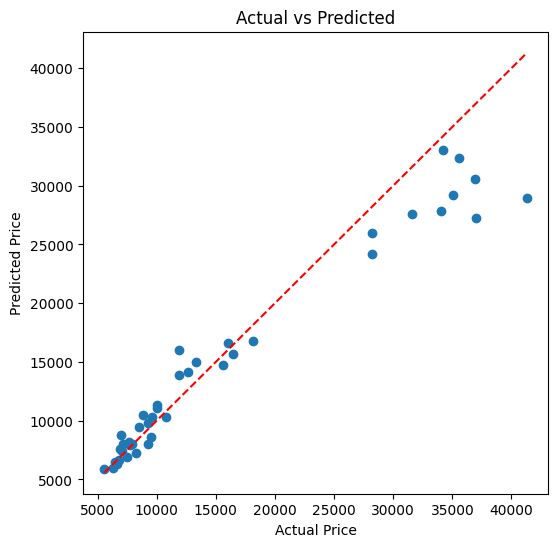

In [13]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.show()

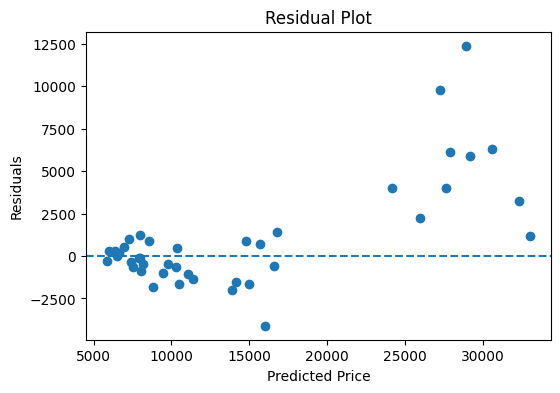

In [14]:
residuals = y_test - pred

plt.figure(figsize=(6,4))

plt.scatter(pred, residuals)

plt.axhline(0, linestyle='--')

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

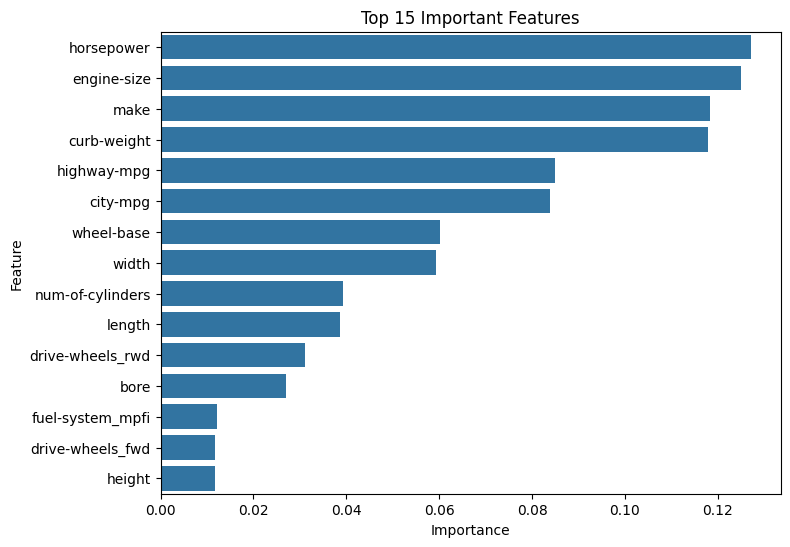

In [15]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance": best_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Important Features")

plt.show()

In [16]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_model, "../models/best_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [17]:
os.makedirs("../reports",exist_ok=True)

tree_results.to_csv("../reports/tree_model_comparison.csv", index=False)
linear_results.to_csv("../reports/linear_model_comparison.csv",index=False)
importance.to_csv("../reports/feature_importance.csv", index=False)